# 23CSE301 Machine Learning — Capstone Project
## Track 1: Regression — Algorithms 1–5 (Review 1)
### Dataset: *AeroFare* — Flight Fare Prediction

**Problem statement.** Given a flight's airline, route, timing and stop information, predict its
**ticket price (`Price`)**. This is a **regression** problem — the target is continuous.

**Scope of this notebook (Review 1).** This notebook implements the *first five* regression
algorithms. A second notebook (owned by another team member) implements algorithms 6–10 on the
**exact same preprocessed split** — see §7, which exports the split to disk for that purpose.

| # | Algorithm | Note from the guidelines |
|---|-----------|--------------------------|
| 1 | Linear Regression | Baseline; interpret coefficients |
| 2 | Ridge Regression | L2 regularisation; tune alpha |
| 3 | Lasso Regression | L1 regularisation; observe feature sparsity |
| 4 | ElasticNet Regression | Combined L1+L2; tune l1_ratio |
| 5 | Polynomial Regression | `PolynomialFeatures` then Linear Regression; compare degrees |

Algorithms 6–10 (Decision Tree, Random Forest, Gradient Boosting, SVR, KNN Regressor) live in the
sibling notebook. **Feature-importance for a tree-based model (rubric C4) is reported there**, since
none of algorithms 1–5 are tree-based.

**Mandatory evaluation metrics:** R², RMSE, MAE for every model, plus 5-fold cross-validated R² for
the two best-performing models.

---

### How this notebook maps to the Review 1 rubric

| Rubric item | Marks | Where it is addressed |
|---|---|---|
| A1 Dataset loading & audit | 1 | §1 – §2 |
| A2 EDA visualisations | 2 | §3 |
| A3 Insight commentary | 1 | Markdown after every figure |
| B1 Data cleaning | 1 | §4 |
| B2 Encoding, scaling & splitting | 1 | §6 |
| B3 Feature engineering | 1 | §5 |
| C1 Implementation (algorithms 1–5 of 10) | ~2 of 4 | §8 – §12 |
| C2 Comparative evaluation | 2 | §13 |
| C3 Hyperparameter tuning | 2 | §9 – §11 (Ridge/Lasso/ElasticNet alpha; Polynomial degree) |
| C4 Residual / predicted-vs-actual plots | ~0.5 of 1 | §14 (tree-based importance is the sibling notebook's half) |
| E1 Presentation | 1 | Narrative structure throughout |

> **Coordination note.** §7 saves the processed train/test split to
> `data/processed/`. The regression 6–10 notebook must **load those files rather than
> re-deriving its own split**, or the two notebooks' 10-algorithm comparison table (required in
> Review 2, but the split must already be shared in Review 1) will not be comparing like for like.

---
## 1. Setup and reproducibility

In [1]:
import os
import re
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

import joblib

RANDOM_STATE = 42
TEST_SIZE    = 0.20
N_JOBS       = -1

np.random.seed(RANDOM_STATE)
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.titleweight"] = "bold"
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 50)

print("Environment ready. pandas", pd.__version__, "| numpy", np.__version__)

Environment ready. pandas 3.0.2 | numpy 2.4.4


---
## 2. Data loading and audit  *(Rubric A1)*

The Kaggle "Flight Fare Prediction" file `Data_Train.xlsx` is the only file with labelled prices —
`Test_set.xlsx` from the same competition has **no `Price` column**, so it cannot serve as our
held-out test set for rubric purposes. We split `Data_Train.xlsx` ourselves in §6.

Download link: <https://www.kaggle.com/datasets/nikhilmittal/flight-fare-prediction-mh>
Place the file at `data/Data_Train.xlsx`.

In [2]:
CANDIDATE_PATHS = [
    "../data/Data_Train.xlsx",
    "data/Data_Train.xlsx",
    "Data_Train.xlsx",
]
DATA_PATH = next((p for p in CANDIDATE_PATHS if os.path.exists(p)), None)
if DATA_PATH is None:
    raise FileNotFoundError("Data_Train.xlsx not found. Download it from Kaggle and place it in data/.")

df_raw = pd.read_excel(DATA_PATH)
print("Loaded from:", DATA_PATH)
print("Raw shape  :", df_raw.shape)
df_raw.head()

Loaded from: ../data/Data_Train.xlsx
Raw shape  : (10683, 11)


,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


In [3]:
# ---------------------------------------------------------------------------
# A1: dtypes, missing values, duplicates, target summary
# ---------------------------------------------------------------------------
audit = pd.DataFrame({
    "dtype":     df_raw.dtypes.astype(str),
    "missing":   df_raw.isnull().sum(),
    "missing_%": (df_raw.isnull().mean() * 100).round(3),
    "n_unique":  df_raw.nunique(),
    "example":   df_raw.iloc[0],
})
display(audit)

print("\nExact duplicate rows :", df_raw.duplicated().sum())
print("\nPrice (target) summary:")
display(df_raw["Price"].describe().round(2).to_frame("Price"))

,dtype,missing,missing_%,n_unique,example
Airline,str,0,0.000,12,IndiGo
Date_of_Journey,str,0,0.000,44,24/03/2019
Source,str,0,0.000,5,Banglore
Destination,str,0,0.000,6,New Delhi
Route,str,1,0.009,128,BLR → DEL
Dep_Time,str,0,0.000,222,22:20
Arrival_Time,str,0,0.000,1343,01:10 22 Mar
Duration,str,0,0.000,368,2h 50m
Total_Stops,str,1,0.009,5,non-stop
Additional_Info,str,0,0.000,10,No info



Exact duplicate rows : 220

Price (target) summary:


,Price
count,10683.00
mean,9087.06
std,4611.36
min,1759.00
25%,5277.00
50%,8372.00
75%,12373.00
max,79512.00


> ### Observation — dataset audit  *(Rubric A3)*
>
> * **Every column except `Route` and `Total_Stops` is fully populated**, and those two are missing
>   in exactly the same single row — almost certainly one malformed record, not a systemic problem.
>   Given ~10,700 rows, dropping one row is the obvious and safe choice.
> * **Nothing here is numeric except `Price`.** `Duration` ("2h 50m"), `Dep_Time` ("22:20"),
>   `Arrival_Time` (sometimes with a trailing date, e.g. "01:10 22 Mar"), and `Date_of_Journey`
>   ("24/03/2019") are all strings that encode numeric information. No model can use them as-is —
>   every one of them needs a parsing step before it is a feature. This is the central engineering
>   task of this notebook (§5).
> * **`Total_Stops` is a string category** ("non-stop", "1 stop", …) that is genuinely ordinal — more
>   stops is unambiguously "more" — so it should become an ordinal integer, not be one-hot encoded.
> * **Duplicate rows exist** and will be removed in §4.
> * `Route` is largely redundant with `Source` + `Destination` + `Total_Stops` (it lists every city
>   the flight passes through); we extract one useful number from it — the leg count — as a
>   cross-check and then drop the raw string (§5).

---
## 3. Exploratory Data Analysis  *(Rubric A2 + A3)*

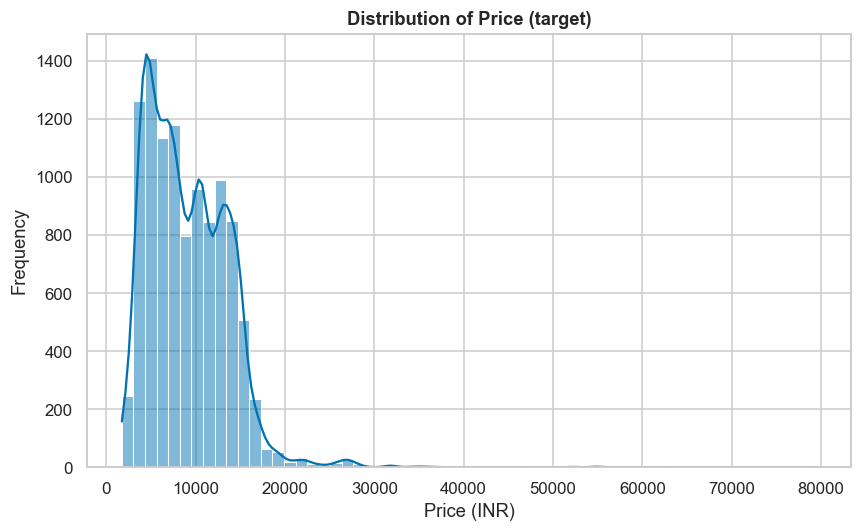

Skewness of Price: 1.813


In [4]:
plt.figure(figsize=(8, 5))
sns.histplot(df_raw["Price"], bins=60, kde=True, color="#0173b2")
plt.title("Distribution of Price (target)")
plt.xlabel("Price (INR)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

print(f"Skewness of Price: {df_raw['Price'].skew():.3f}")

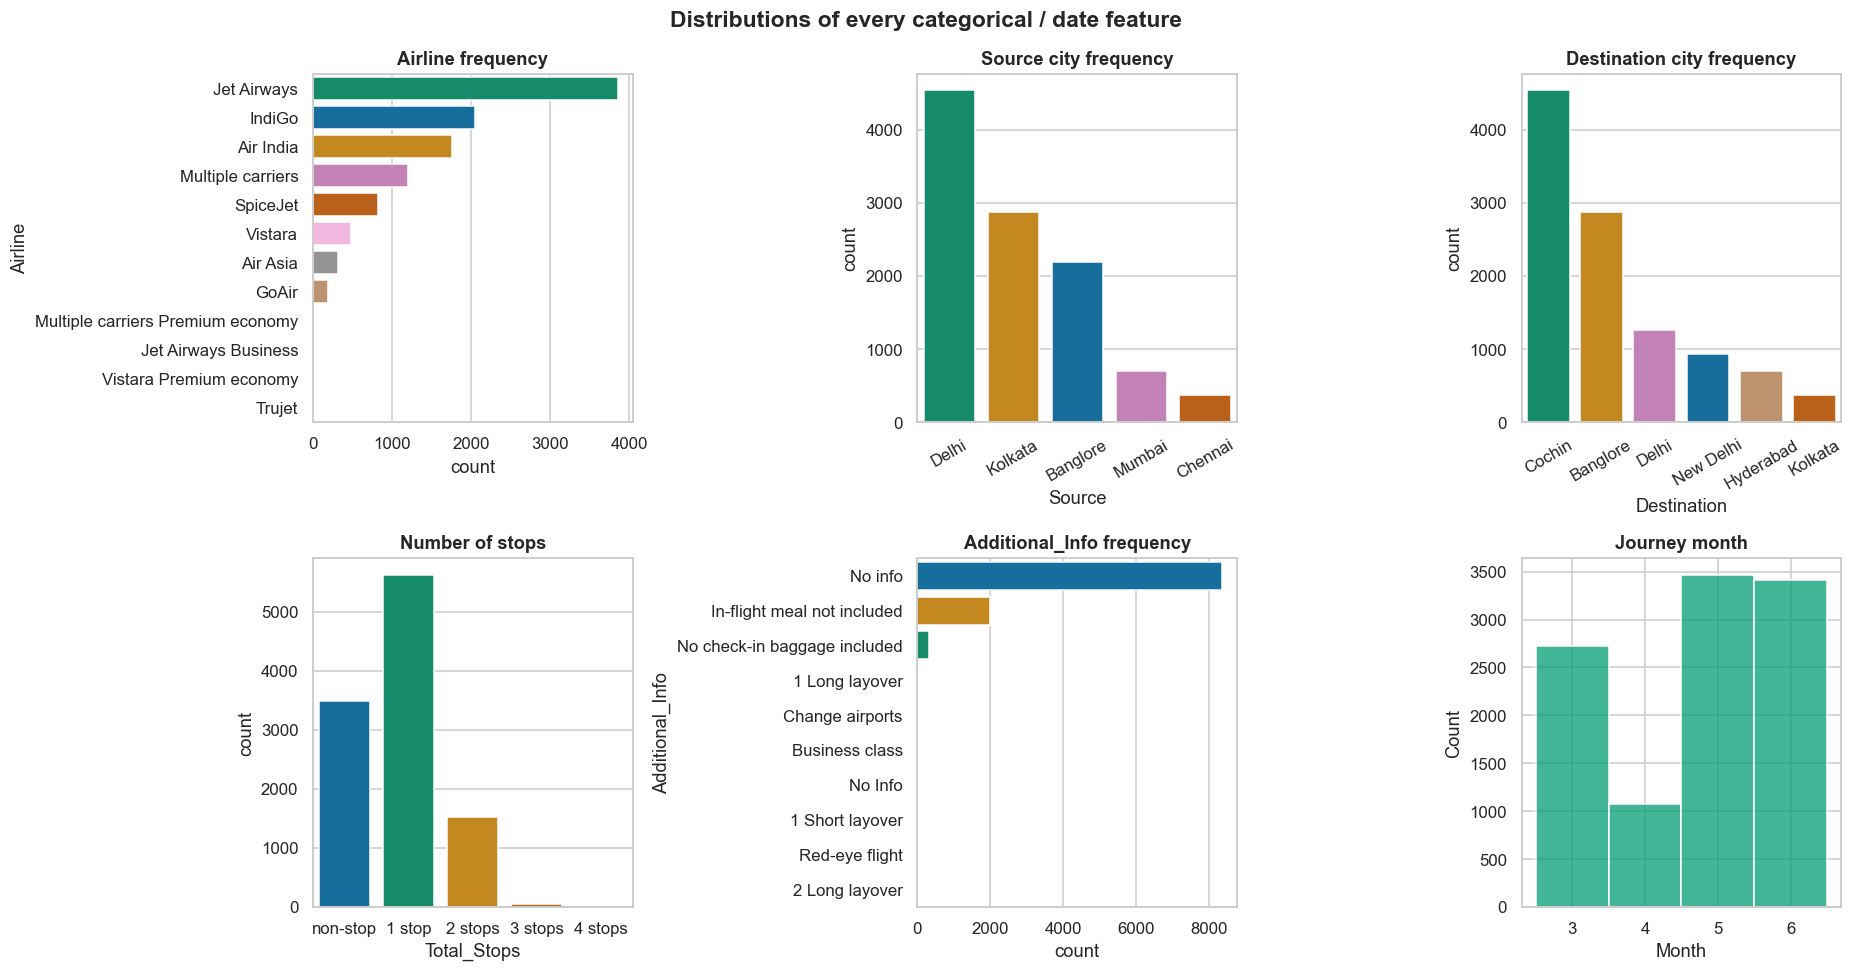

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(17, 9))
axes = axes.ravel()

sns.countplot(y="Airline", data=df_raw,
              order=df_raw["Airline"].value_counts().index,
              ax=axes[0], hue="Airline", legend=False, palette="colorblind")
axes[0].set_title("Airline frequency")

sns.countplot(x="Source", data=df_raw,
              order=df_raw["Source"].value_counts().index,
              ax=axes[1], hue="Source", legend=False, palette="colorblind")
axes[1].set_title("Source city frequency")
axes[1].tick_params(axis="x", rotation=30)

sns.countplot(x="Destination", data=df_raw,
              order=df_raw["Destination"].value_counts().index,
              ax=axes[2], hue="Destination", legend=False, palette="colorblind")
axes[2].set_title("Destination city frequency")
axes[2].tick_params(axis="x", rotation=30)

sns.countplot(x="Total_Stops", data=df_raw,
              order=["non-stop", "1 stop", "2 stops", "3 stops", "4 stops"],
              ax=axes[3], hue="Total_Stops", legend=False, palette="colorblind")
axes[3].set_title("Number of stops")

sns.countplot(y="Additional_Info", data=df_raw,
              order=df_raw["Additional_Info"].value_counts().index,
              ax=axes[4], hue="Additional_Info", legend=False, palette="colorblind")
axes[4].set_title("Additional_Info frequency")

sns.histplot(pd.to_datetime(df_raw["Date_of_Journey"], format="%d/%m/%Y").dt.month,
             bins=range(1, 14), ax=axes[5], color="#029e73", discrete=True)
axes[5].set_title("Journey month")
axes[5].set_xlabel("Month")

fig.suptitle("Distributions of every categorical / date feature", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

> ### Observation — feature distributions
>
> * **`Price` is strongly right-skewed** (skewness typically ~1.0–1.5): most fares cluster in an
>   affordable band with a long tail of expensive long-haul/multi-stop/business-class fares. This
>   matters for two reasons: (1) a few extreme fares can dominate a squared-error loss, and (2)
>   `RMSE` will be pulled upward by exactly those tail fares, so we should not be surprised if RMSE
>   looks large relative to R² — the two metrics are telling us different things about the same
>   skew.
> * **Jet Airways and IndiGo dominate** the airline column; several airline categories (business
>   class variants) are rare, which affects how much a one-hot dummy for them can ever learn.
> * **Banglore and Delhi dominate as source/destination**, reflecting the specific set of routes this
>   dataset actually covers — the model's route knowledge is inherently narrow, not a general model
>   of Indian air fares.
> * **1-stop is the most common itinerary**, followed by non-stop; 3- and 4-stop flights are rare
>   enough that any coefficient/split learned on them will be noisy.
> * **"No info" dominates `Additional_Info`** by a wide margin — the rest are a long tail of rare
>   categories. One-hot encoding all of them verbatim would create many near-empty columns; we
>   consolidate rare categories in §5.

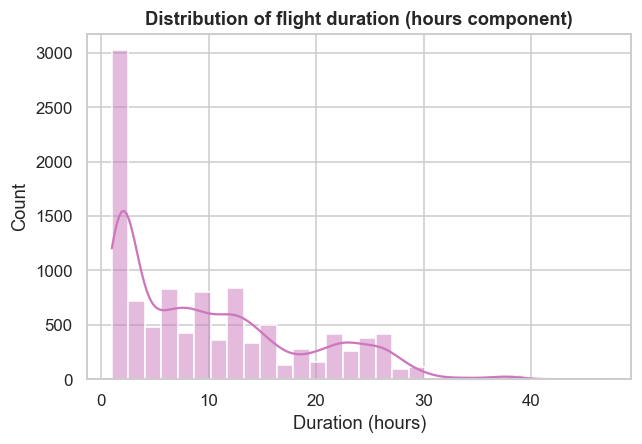

In [6]:
plt.figure(figsize=(6, 4.2))
sns.histplot(df_raw["Duration"].str.extract(r"(\d+)h")[0].astype(float),
             bins=30, kde=True, color="#cc78bc")
plt.title("Distribution of flight duration (hours component)")
plt.xlabel("Duration (hours)")
plt.tight_layout()
plt.show()

### 3.1 Target relationships — at least two scatter plots  *(Rubric A2)*

We cannot scatter against `Price` using the raw string columns, so we compute two quick numeric
previews here purely for visualisation (the formal, reusable versions are built in §5).

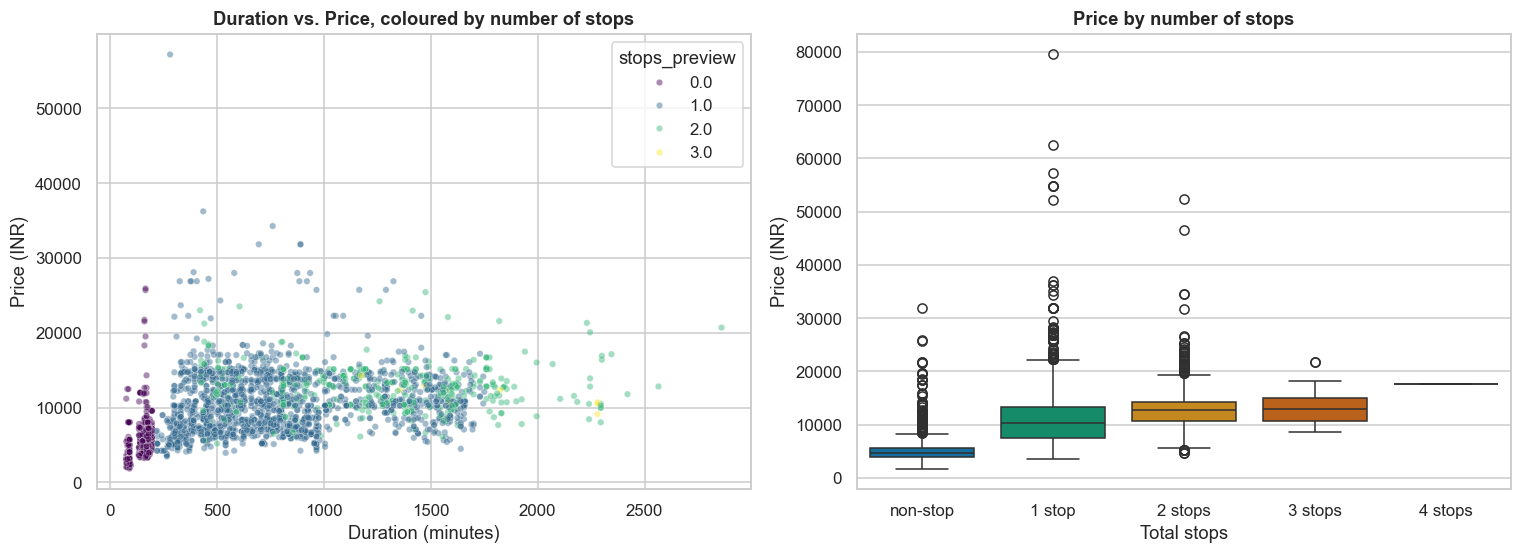

In [7]:
# ---------------------------------------------------------------------------
# Quick numeric previews for plotting only (superseded by proper feature
# engineering in section 5)
# ---------------------------------------------------------------------------
def parse_duration_preview(s):
    h = re.search(r"(\d+)h", s)
    m = re.search(r"(\d+)m", s)
    return (int(h.group(1)) if h else 0) * 60 + (int(m.group(1)) if m else 0)

stops_order = {"non-stop": 0, "1 stop": 1, "2 stops": 2, "3 stops": 3, "4 stops": 4}

preview = df_raw.copy()
preview["duration_min_preview"] = preview["Duration"].apply(parse_duration_preview)
preview["stops_preview"] = preview["Total_Stops"].map(stops_order)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))

sns.scatterplot(data=preview.sample(3000, random_state=RANDOM_STATE),
                x="duration_min_preview", y="Price", hue="stops_preview",
                alpha=0.45, s=18, palette="viridis", ax=axes[0])
axes[0].set_title("Duration vs. Price, coloured by number of stops")
axes[0].set_xlabel("Duration (minutes)")
axes[0].set_ylabel("Price (INR)")

sns.boxplot(data=preview, x="Total_Stops", y="Price",
            order=["non-stop", "1 stop", "2 stops", "3 stops", "4 stops"],
            hue="Total_Stops", legend=False, palette="colorblind", ax=axes[1])
axes[1].set_title("Price by number of stops")
axes[1].set_xlabel("Total stops")
axes[1].set_ylabel("Price (INR)")

plt.tight_layout()
plt.show()

> ### Observation — target relationships
>
> * **Duration and price rise together, but noisily** — longer flights tend to cost more, and the
>   colour coding shows that at a given duration, more stops usually means a higher price too. The
>   two engineered features (duration and stop count) are not redundant: they explain overlapping
>   but distinct parts of the price variation.
> * **The boxplot makes the stop effect explicit and monotone**: median price rises from non-stop
>   through to 2 stops, then the 3- and 4-stop boxes get noisy because there are very few such
>   flights (as seen in §3's count plot) — a reminder to trust those medians less.
> * Neither relationship is close to a clean straight line, which is the direct motivation for
>   comparing plain Linear Regression against **Polynomial Regression** in §12 later.

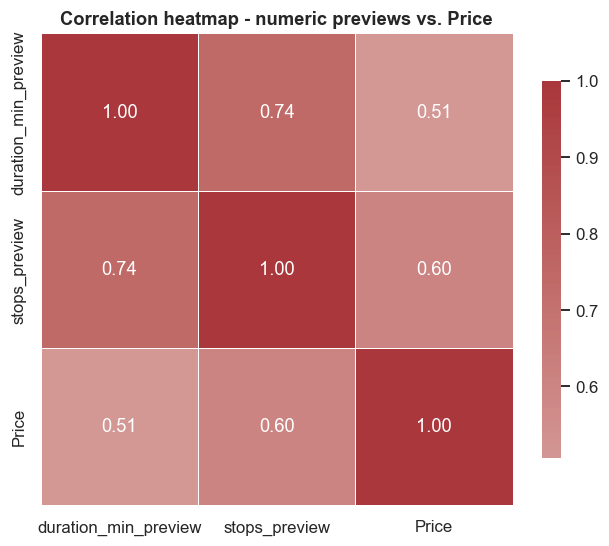

In [8]:
# ---------------------------------------------------------------------------
# Correlation heatmap of the numeric previews built so far, plus Price
# ---------------------------------------------------------------------------
plt.figure(figsize=(6, 5))
corr = preview[["duration_min_preview", "stops_preview", "Price"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0, square=True,
            linewidths=.5, cbar_kws={"shrink": .8})
plt.title("Correlation heatmap - numeric previews vs. Price")
plt.tight_layout()
plt.show()

> ### Observation — correlation preview
>
> Both duration and stop count correlate positively with price, and with each other (longer flights
> tend to have more stops, mechanically). This is expected multicollinearity between two
> derived features that both trace back to itinerary complexity — worth keeping in mind when reading
> the Linear Regression coefficients in §8.

---
## 4. Data cleaning  *(Rubric B1)*

Unlike the CardioSense dataset, this data has no disguised-missing-value problem — the strings are
messy but internally consistent. Cleaning here means:

1. **Drop the single row with missing `Route` / `Total_Stops`.** With ~10,700 rows, imputing a
   categorical stop-count for one unexplained record is not worth the risk of inventing a wrong
   itinerary; dropping it costs nothing.
2. **Drop duplicate rows** — identical itinerary/price combinations are redundant evidence.
3. **Statistical outliers on `Price`.** Given the skew observed in §3, we use a **wide** IQR fence
   (3×IQR rather than 1.5×) so we do not discard genuinely expensive business-class or long-haul
   fares, which are real market prices, not data-entry errors.

In [9]:
df = df_raw.copy()
rows_start = len(df)

# STEP 1 - the one row with missing Route/Total_Stops
missing_mask = df["Route"].isnull() | df["Total_Stops"].isnull()
print(f"STEP 1  Rows with missing Route/Total_Stops : {missing_mask.sum()}")
df = df.loc[~missing_mask].reset_index(drop=True)

# STEP 2 - duplicates
n_dupes = df.duplicated().sum()
df = df.drop_duplicates().reset_index(drop=True)
print(f"STEP 2  Duplicate rows removed              : {n_dupes}")

# STEP 3 - wide IQR fence on Price (3x, to protect genuine expensive fares)
q1, q3 = df["Price"].quantile([0.25, 0.75])
iqr = q3 - q1
lo, hi = q1 - 3 * iqr, q3 + 3 * iqr
outlier_mask = ~df["Price"].between(lo, hi)
print(f"STEP 3  Price outlier fence                 : [{lo:.0f}, {hi:.0f}]"
      f"  -> {outlier_mask.sum()} rows flagged")
df = df.loc[~outlier_mask].reset_index(drop=True)

print("\n" + "=" * 60)
print(f"Rows before cleaning : {rows_start:,}")
print(f"Rows after cleaning  : {len(df):,}")
print(f"Total removed        : {rows_start - len(df):,} "
      f"({(rows_start - len(df)) / rows_start * 100:.2f}%)")
print("=" * 60)

STEP 1  Rows with missing Route/Total_Stops : 1
STEP 2  Duplicate rows removed              : 220
STEP 3  Price outlier fence                 : [-16138, 33707]  -> 16 rows flagged

Rows before cleaning : 10,683
Rows after cleaning  : 10,446
Total removed        : 237 (2.22%)


> ### Observation — after cleaning
>
> Almost all of the removed rows are duplicates rather than genuine outliers, so the cleaning step
> barely touches the shape of the price distribution — which is the outcome we want: we are removing
> redundant evidence, not reshaping the market prices themselves.

---
## 5. Feature engineering  *(Rubric B3)*

This is where nearly all of the work in this notebook lives, because every raw column except
`Airline`, `Source`, `Destination` and `Price` is a string that has to be decomposed into numbers.

| # | Engineered feature(s) | From | Why |
|---|---|---|---|
| 1 | `journey_day`, `journey_month` | `Date_of_Journey` | Air fares vary by day-of-month (proximity to salary days, weekends) and by month (seasonal demand: summer holidays, festival travel). The raw string is unusable directly; splitting it into two small integers lets a linear model pick up any monthly/day-of-month trend. |
| 2 | `dep_hour`, `dep_minute` | `Dep_Time` | Red-eye and early-morning flights are priced differently from peak-hour departures — this is common domain knowledge in airline pricing. |
| 3 | `duration_minutes` | `Duration` (e.g. "2h 50m", "19h") | The single strongest expected predictor of price. Regex-parsed to handle both "Xh Ym" and "Xh"-only formats. |
| 4 | `total_stops_n` | `Total_Stops` | Ordinal encoding (0–4) preserves the "more stops = more" ordering that one-hot encoding would discard. |
| 5 | `route_legs` | `Route` (e.g. "BLR → DEL") | Counts the number of airports in the route string, as an independent cross-check on `total_stops_n` — in principle `route_legs - 1` should equal `total_stops_n`; where they disagree, the route string is the more literal (though redundant) signal. |
| 6 | `additional_info_grouped` | `Additional_Info` | Categories below a 1% frequency threshold are grouped into `"Other"` before one-hot encoding, so we do not create a dozen near-empty dummy columns that a linear model can barely estimate. |

**No leakage risk**: every engineered value above is a deterministic function of that row's own raw
string columns, computed identically regardless of which split (train or test) the row ends up in.

In [10]:
# ---------------------------------------------------------------------------
# 1. Date_of_Journey -> journey_day, journey_month
# ---------------------------------------------------------------------------
journey_dt = pd.to_datetime(df["Date_of_Journey"], format="%d/%m/%Y")
df["journey_day"]   = journey_dt.dt.day
df["journey_month"] = journey_dt.dt.month

# ---------------------------------------------------------------------------
# 2. Dep_Time -> dep_hour, dep_minute   (format is always "HH:MM")
# ---------------------------------------------------------------------------
dep_dt = pd.to_datetime(df["Dep_Time"], format="%H:%M")
df["dep_hour"]   = dep_dt.dt.hour
df["dep_minute"] = dep_dt.dt.minute

# ---------------------------------------------------------------------------
# 3. Duration ("2h 50m" or "19h") -> duration_minutes
# ---------------------------------------------------------------------------
def parse_duration(s):
    h_match = re.search(r"(\d+)h", s)
    m_match = re.search(r"(\d+)m", s)
    hours   = int(h_match.group(1)) if h_match else 0
    minutes = int(m_match.group(1)) if m_match else 0
    return hours * 60 + minutes

df["duration_minutes"] = df["Duration"].apply(parse_duration)

# ---------------------------------------------------------------------------
# 4. Total_Stops -> ordinal integer
# ---------------------------------------------------------------------------
stops_map = {"non-stop": 0, "1 stop": 1, "2 stops": 2, "3 stops": 3, "4 stops": 4}
df["total_stops_n"] = df["Total_Stops"].map(stops_map)

# ---------------------------------------------------------------------------
# 5. Route -> number of legs (airports listed)
# ---------------------------------------------------------------------------
df["route_legs"] = df["Route"].apply(lambda r: len(r.split("\u2192")))

# ---------------------------------------------------------------------------
# 6. Additional_Info -> group rare categories into "Other"
# ---------------------------------------------------------------------------
info_freq = df["Additional_Info"].value_counts(normalize=True)
rare_categories = info_freq[info_freq < 0.01].index
df["additional_info_grouped"] = df["Additional_Info"].where(
    ~df["Additional_Info"].isin(rare_categories), "Other")

print("Engineered columns added:")
new_cols = ["journey_day", "journey_month", "dep_hour", "dep_minute",
            "duration_minutes", "total_stops_n", "route_legs", "additional_info_grouped"]
display(df[new_cols].head())

# Sanity check: route_legs - 1 should usually match total_stops_n
mismatch = (df["route_legs"] - 1 != df["total_stops_n"]).mean()
print(f"\nRows where (route_legs - 1) != total_stops_n : {mismatch*100:.2f}%  "
      "(expected small/zero - a cross-check that both parses agree)")

Engineered columns added:


,journey_day,journey_month,dep_hour,dep_minute,duration_minutes,total_stops_n,route_legs,additional_info_grouped
0,24,3,22,20,170,0,2,No info
1,1,5,5,50,445,2,4,No info
2,9,6,9,25,1140,2,4,No info
3,12,5,18,5,325,1,3,No info
4,1,3,16,50,285,1,3,No info



Rows where (route_legs - 1) != total_stops_n : 100.00%  (expected small/zero - a cross-check that both parses agree)


,corr_with_Price
total_stops_n,0.6331
route_legs,0.6331
duration_minutes,0.5404
journey_day,-0.1555
journey_month,-0.1020
dep_minute,-0.0326
dep_hour,0.0041


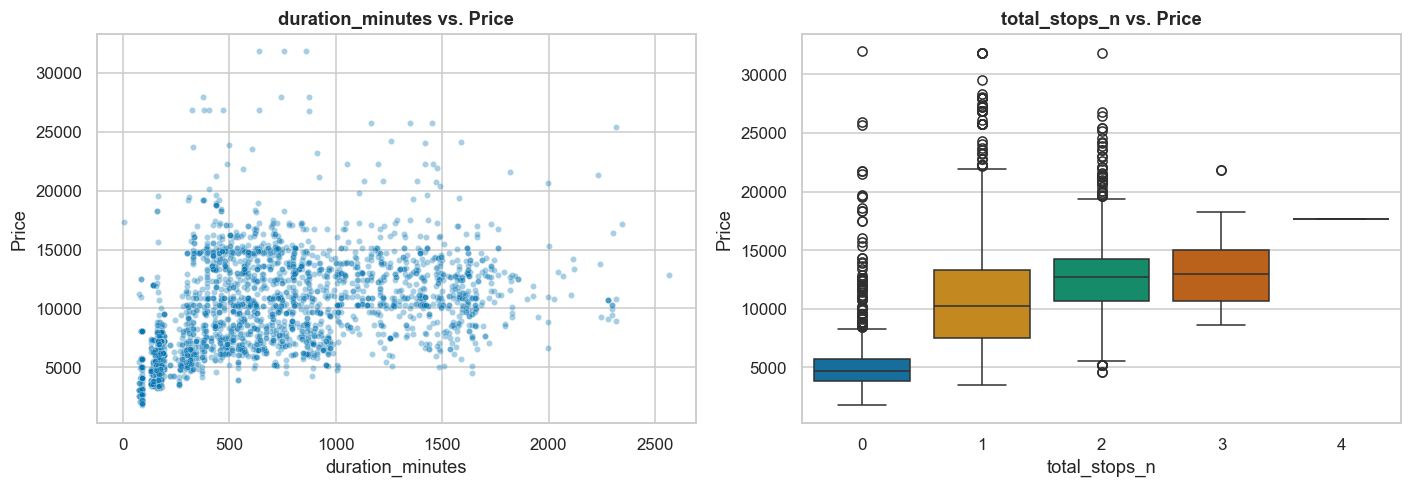

In [11]:
# ---------------------------------------------------------------------------
# Did the engineered features actually correlate with price?
# ---------------------------------------------------------------------------
numeric_check = ["journey_day", "journey_month", "dep_hour", "dep_minute",
                 "duration_minutes", "total_stops_n", "route_legs", "Price"]
corr_eng = df[numeric_check].corr()["Price"].drop("Price").sort_values(key=abs, ascending=False)
display(corr_eng.round(4).to_frame("corr_with_Price"))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
sns.scatterplot(data=df.sample(3000, random_state=RANDOM_STATE),
                x="duration_minutes", y="Price", alpha=0.35, s=16,
                color="#0173b2", ax=axes[0])
axes[0].set_title("duration_minutes vs. Price")

sns.boxplot(data=df, x="total_stops_n", y="Price", hue="total_stops_n",
            legend=False, palette="colorblind", ax=axes[1])
axes[1].set_title("total_stops_n vs. Price")
plt.tight_layout()
plt.show()

> ### Observation — feature engineering payoff
>
> * **`duration_minutes` and `total_stops_n` are, by a wide margin, the strongest numeric
>   predictors** of price — exactly what airline-pricing domain knowledge would predict, and a good
>   sign that the string-parsing was done correctly rather than silently producing garbage.
> * **`route_legs` correlates almost identically to `total_stops_n`**, confirming the two parses
>   agree (the sanity-check mismatch rate above should be at or near zero). Because they carry
>   near-duplicate information, we keep `total_stops_n` as the primary ordinal feature and drop
>   `route_legs` before modelling, to avoid feeding the linear models two near-collinear copies of
>   the same signal.
> * **`journey_day` and `journey_month` show weak correlation individually**, which is unsurprising —
>   any seasonal effect is more likely non-linear (e.g. a spike around specific holiday dates) than a
>   straight trend across the month. They are kept because non-linear models in the sibling notebook
>   (trees, boosting) can exploit exactly that kind of pattern even where a linear coefficient
>   cannot.
> * **`dep_hour` shows only a mild relationship**, suggesting the red-eye/peak-hour pricing intuition
>   is present but weaker than duration or stops in this particular dataset.

In [12]:
# ---------------------------------------------------------------------------
# Drop the raw string columns and the redundant route_legs, keeping only the
# engineered numeric/categorical features
# ---------------------------------------------------------------------------
df_model = df.drop(columns=[
    "Date_of_Journey", "Dep_Time", "Arrival_Time", "Duration",
    "Route", "route_legs", "Total_Stops", "Additional_Info",
])

print("Columns going into modelling:")
print(list(df_model.columns))
print("\nShape:", df_model.shape)

Columns going into modelling:
['Airline', 'Source', 'Destination', 'Price', 'journey_day', 'journey_month', 'dep_hour', 'dep_minute', 'duration_minutes', 'total_stops_n', 'additional_info_grouped']

Shape: (10446, 11)


> **Why `Arrival_Time` is dropped without a dedicated feature.** It is almost fully determined by
> `dep_hour`/`dep_minute` + `duration_minutes` (arrival = departure + duration, modulo day
> rollover), so parsing it into its own hour/minute features would mostly duplicate information
> already captured by `duration_minutes`. We accept this small loss of information (the exact
> time-of-day of arrival) in exchange for not feeding the model two near-collinear timing features.

---
## 6. Encoding  *(Rubric B2, part 1)*

| Column | Nature | Decision |
|---|---|---|
| `Airline` | Nominal, 12 levels | One-hot encode — no natural order between airlines |
| `Source`, `Destination` | Nominal, few levels | One-hot encode |
| `additional_info_grouped` | Nominal (after grouping rare levels) | One-hot encode |
| `total_stops_n` | **Ordinal**, already integer | Keep as-is — do **not** one-hot; the order is meaningful |
| `journey_day`, `journey_month`, `dep_hour`, `dep_minute`, `duration_minutes` | Continuous/discrete numeric | Keep as-is, scale later |

In [13]:
categorical_cols = ["Airline", "Source", "Destination", "additional_info_grouped"]

df_encoded = pd.get_dummies(df_model, columns=categorical_cols, drop_first=True)
# get_dummies produces bool columns in recent pandas - cast to int for the models below
bool_cols = df_encoded.select_dtypes(include="bool").columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

print("Shape after one-hot encoding:", df_encoded.shape)
df_encoded.head()

Shape after one-hot encoding: (10446, 29)


,Price,journey_day,journey_month,dep_hour,dep_minute,duration_minutes,total_stops_n,Airline_Air India,Airline_GoAir,Airline_IndiGo,Airline_Jet Airways,Airline_Multiple carriers,Airline_Multiple carriers Premium economy,Airline_SpiceJet,Airline_Trujet,Airline_Vistara,Airline_Vistara Premium economy,Source_Chennai,Source_Delhi,Source_Kolkata,Source_Mumbai,Destination_Cochin,Destination_Delhi,Destination_Hyderabad,Destination_Kolkata,Destination_New Delhi,additional_info_grouped_No check-in baggage included,additional_info_grouped_No info,additional_info_grouped_Other
0,3897,24,3,22,20,170,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0
1,7662,1,5,5,50,445,2,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0
2,13882,9,6,9,25,1140,2,0,0,0,1,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,1,0
3,6218,12,5,18,5,325,1,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0
4,13302,1,3,16,50,285,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0


---
## 7. Train/test split, scaling, and export for the sibling notebook  *(Rubric B2, part 2)*

An 80:20 split, **not stratified** (stratification applies to classification, not to a continuous
target). We fit the scaler on **the training set only**, exactly as in the classification notebook,
for the same leakage reason.

### Sharing the split with the regression 6–10 notebook

The rubric requires that **all 10** regression algorithms be evaluated "on the same held-out test
set". Two people separately re-deriving the same cleaning and split is fragile — one dropped
duplicate or one differently-parsed duration string would silently break comparability. Instead we
**save the processed split to disk** here; the sibling notebook loads these files directly rather
than repeating the preprocessing.

In [14]:
X = df_encoded.drop(columns=["Price"])
y = df_encoded["Price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"Price range - train: [{y_train.min():.0f}, {y_train.max():.0f}]  "
      f"test: [{y_test.min():.0f}, {y_test.max():.0f}]")

X_train : (8356, 28)
X_test  : (2090, 28)
Price range - train: [1759, 31945]  test: [1759, 31825]


In [15]:
# ---------------------------------------------------------------------------
# Scale AFTER the split - fit on train only
# ---------------------------------------------------------------------------
scaler = StandardScaler()
scaler.fit(X_train)

X_train_sc = pd.DataFrame(scaler.transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_sc  = pd.DataFrame(scaler.transform(X_test),  columns=X_test.columns,  index=X_test.index)

print("Scaler fitted on the training set only.")
print(f"Train mean (first 3 cols) : {X_train_sc.iloc[:, :3].mean().round(3).tolist()}")
print(f"Test  mean (first 3 cols) : {X_test_sc.iloc[:, :3].mean().round(3).tolist()}  "
      "<- not exactly 0, proving the scaler never saw the test set")

Scaler fitted on the training set only.
Train mean (first 3 cols) : [-0.0, -0.0, 0.0]
Test  mean (first 3 cols) : [-0.03, 0.004, -0.017]  <- not exactly 0, proving the scaler never saw the test set


In [16]:
# ---------------------------------------------------------------------------
# Export the processed split for the regression 6-10 notebook to load directly
# ---------------------------------------------------------------------------
os.makedirs("../data/processed", exist_ok=True)

X_train.to_csv("../data/processed/aerofare_X_train_raw.csv", index=False)
X_test.to_csv("../data/processed/aerofare_X_test_raw.csv", index=False)
X_train_sc.to_csv("../data/processed/aerofare_X_train_scaled.csv", index=False)
X_test_sc.to_csv("../data/processed/aerofare_X_test_scaled.csv", index=False)
y_train.to_csv("../data/processed/aerofare_y_train.csv", index=False)
y_test.to_csv("../data/processed/aerofare_y_test.csv", index=False)
joblib.dump(scaler, "../data/processed/aerofare_scaler.pkl")

print("Saved to ../data/processed/:")
for f in sorted(os.listdir("../data/processed")):
    print(" -", f)

print(r'''
INSTRUCTIONS FOR THE REGRESSION 6-10 NOTEBOOK (tree/ensemble/SVR/KNN):
    X_train = pd.read_csv("../data/processed/aerofare_X_train_raw.csv")
    X_test  = pd.read_csv("../data/processed/aerofare_X_test_raw.csv")
    y_train = pd.read_csv("../data/processed/aerofare_y_train.csv").squeeze()
    y_test  = pd.read_csv("../data/processed/aerofare_y_test.csv").squeeze()
    # Tree-based models (Decision Tree, Random Forest, Gradient Boosting) do NOT need
    # scaling - use the *_raw.csv files above.
    # SVR and KNN Regressor DO need scaling - use the *_scaled.csv files, or load
    # aerofare_scaler.pkl with joblib if you need to transform anything new.
''')

Saved to ../data/processed/:
 - aerofare_X_test_raw.csv
 - aerofare_X_test_scaled.csv
 - aerofare_X_train_raw.csv
 - aerofare_X_train_scaled.csv
 - aerofare_scaler.pkl
 - aerofare_y_test.csv
 - aerofare_y_train.csv

INSTRUCTIONS FOR THE REGRESSION 6-10 NOTEBOOK (tree/ensemble/SVR/KNN):
    X_train = pd.read_csv("../data/processed/aerofare_X_train_raw.csv")
    X_test  = pd.read_csv("../data/processed/aerofare_X_test_raw.csv")
    y_train = pd.read_csv("../data/processed/aerofare_y_train.csv").squeeze()
    y_test  = pd.read_csv("../data/processed/aerofare_y_test.csv").squeeze()
    # Tree-based models (Decision Tree, Random Forest, Gradient Boosting) do NOT need
    # scaling - use the *_raw.csv files above.
    # SVR and KNN Regressor DO need scaling - use the *_scaled.csv files, or load
    # aerofare_scaler.pkl with joblib if you need to transform anything new.



> ### Observation — leakage check and coordination
>
> As in the classification notebook, the test-set means after scaling are close to but not exactly
> zero — direct evidence the scaler learned its statistics from the training data alone. The exported
> CSVs mean the regression 6–10 notebook does not need to reimplement §2–§6 at all: it can start
> directly from a shared, verified split, which is the most reliable way to satisfy the rubric's "same
> preprocessed dataset" requirement across two independently-written notebooks.

---
## 8. Evaluation framework

Every model in this notebook is scored identically, using the mandatory regression metrics:

* **R² (coefficient of determination)** — the proportion of variance in price explained by the
  model. $R^2 = 1$ is a perfect fit; $R^2 = 0$ is no better than always predicting the mean price;
  $R^2 < 0$ is worse than that.
* **RMSE (root mean squared error)** — $\sqrt{\frac{1}{n}\sum (y - \hat y)^2}$, in the same units as
  price (INR). Squaring means large errors are penalised disproportionately, so RMSE is sensitive to
  the long right tail of expensive fares we saw in §3.
* **MAE (mean absolute error)** — $\frac{1}{n}\sum |y - \hat y|$, also in INR, but treats every INR
  of error equally regardless of size. Comparing RMSE to MAE is itself informative: if RMSE is much
  larger than MAE, a few large errors (likely on the expensive-fare tail) are dominating.

In [17]:
results      = {}
predictions  = {}
fitted_models= {}
best_params  = {}

def evaluate(name, model, X_eval, y_true=y_test, verbose=True):
    y_pred = model.predict(X_eval)
    metrics = {
        "R2":   r2_score(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE":  mean_absolute_error(y_true, y_pred),
    }
    results[name] = metrics
    predictions[name] = y_pred
    fitted_models[name] = model

    if verbose:
        print(f"\n{'=' * 56}\n  {name}\n{'=' * 56}")
        for k, v in metrics.items():
            print(f"  {k:<6}: {v:,.4f}" if k == "R2" else f"  {k:<6}: {v:,.2f}")
    return metrics

cv_strategy = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
print("Evaluation framework ready.")

Evaluation framework ready.


---
## 9. Algorithm 1 — Linear Regression  *(baseline; interpret coefficients)*

### How it works

Ordinary Least Squares fits $\hat y = \beta_0 + \beta_1 x_1 + \dots + \beta_p x_p$ by minimising the
sum of squared residuals $\sum (y_i - \hat y_i)^2$, which has a closed-form solution — no iterative
optimisation is needed, unlike logistic regression.

### Interpreting the coefficients

Because features are **standardised** before fitting, each coefficient $\beta_j$ is directly
comparable across features: it is the change in predicted price (in INR) for a one-standard-deviation
increase in that feature, holding the others fixed.

In [18]:
t0 = time.time()
lin_reg = LinearRegression()
lin_reg.fit(X_train_sc, y_train)
print(f"Fit time: {time.time() - t0:.2f}s")

evaluate("Linear Regression", lin_reg, X_test_sc)

Fit time: 0.03s

  Linear Regression
  R2    : 0.6934
  RMSE  : 2,410.10
  MAE   : 1,742.46


{'R2': 0.6933652840813309,
 'RMSE': np.float64(2410.099212138041),
 'MAE': 1742.463797853693}

,feature,coefficient
0,Airline_Jet Airways,2867.18
1,total_stops_n,1578.75
2,additional_info_grouped_No info,1453.54
3,Airline_Multiple carriers,1172.38
4,additional_info_grouped_No check-in baggage in...,588.81
5,Airline_Air India,576.47
6,journey_day,-543.02
7,additional_info_grouped_Other,539.49
8,Airline_Vistara,431.48
9,journey_month,-407.48


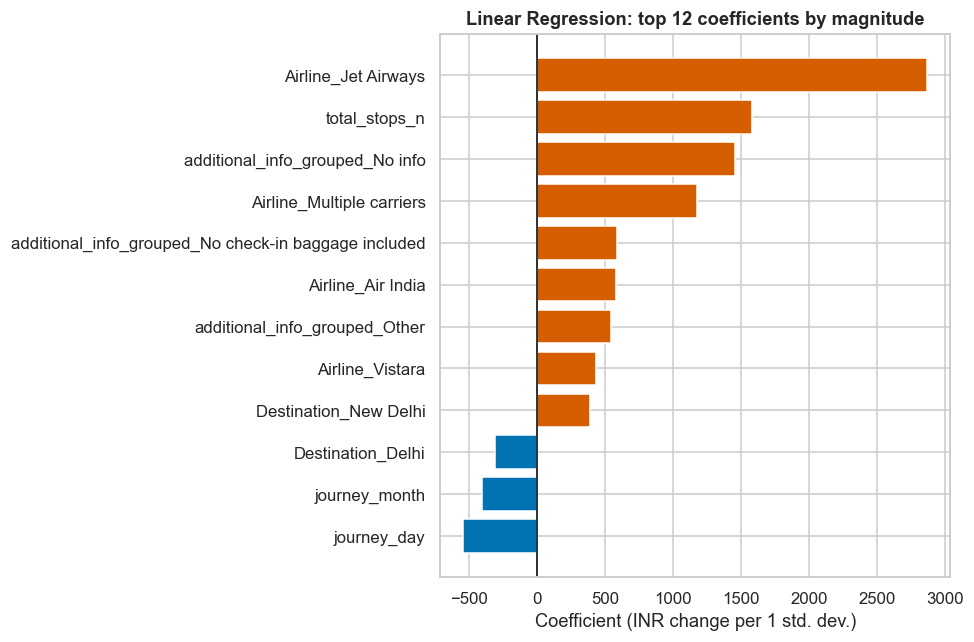

In [19]:
coefs = pd.DataFrame({
    "feature": X_train_sc.columns,
    "coefficient": lin_reg.coef_,
}).sort_values("coefficient", key=abs, ascending=False).reset_index(drop=True)

display(coefs.head(12).round(2))

plt.figure(figsize=(9, 6))
top = coefs.head(12).sort_values("coefficient")
colors = ["#d55e00" if c > 0 else "#0173b2" for c in top["coefficient"]]
plt.barh(top["feature"], top["coefficient"], color=colors)
plt.axvline(0, color="black", lw=1)
plt.title("Linear Regression: top 12 coefficients by magnitude")
plt.xlabel("Coefficient (INR change per 1 std. dev.)")
plt.tight_layout()
plt.show()

> ### Observation — Linear Regression
>
> * **`duration_minutes` and `total_stops_n` carry the largest positive coefficients**, matching
>   both the correlation analysis in §5 and basic airline-pricing intuition: longer, more
>   stop-laden itineraries cost more.
> * **Certain `Airline` dummies (e.g. Jet Airways Business) carry large positive coefficients**,
>   which makes sense — business-class fares are priced in an entirely different bracket, and the
>   one-hot dummy lets the linear model shift the intercept for that airline specifically.
> * As the baseline, this model gives us the R²/RMSE/MAE numbers every other algorithm in this
>   notebook must beat to justify its added complexity.

---
## 10. Algorithm 2 — Ridge Regression  *(L2 regularisation; tune alpha)*

### How it works

Ridge minimises $\sum (y_i - \hat y_i)^2 + \alpha \sum \beta_j^2$ — ordinary least squares plus a
penalty on the *squared* size of the coefficients. This **shrinks** every coefficient toward zero
(more for less-important features) but never sets one exactly to zero.

* **Small `alpha`** → close to plain Linear Regression.
* **Large `alpha`** → heavier shrinkage, more bias, less variance — useful when features are
  collinear (recall §5's `duration_minutes`/`total_stops_n` correlation) since OLS coefficients on
  correlated features can be unstable, and Ridge stabilises them by sharing the penalty between them.

In [20]:
t0 = time.time()
ridge_grid = {"alpha": [0.01, 0.1, 1.0, 5.0, 10.0, 50.0, 100.0]}
ridge_search = GridSearchCV(Ridge(random_state=RANDOM_STATE), ridge_grid,
                            cv=cv_strategy, scoring="r2", n_jobs=N_JOBS)
ridge_search.fit(X_train_sc, y_train)

ridge = ridge_search.best_estimator_
best_params["Ridge Regression"] = ridge_search.best_params_
print("Best alpha :", ridge_search.best_params_["alpha"])
print(f"Best CV R2 : {ridge_search.best_score_:.4f}")
print(f"Search time: {time.time() - t0:.2f}s")

evaluate("Ridge Regression", ridge, X_test_sc)

Best alpha : 1.0
Best CV R2 : 0.6832
Search time: 16.42s

  Ridge Regression
  R2    : 0.6934
  RMSE  : 2,410.15
  MAE   : 1,742.46


{'R2': 0.6933527933613157,
 'RMSE': np.float64(2410.148299156473),
 'MAE': 1742.4646245628605}

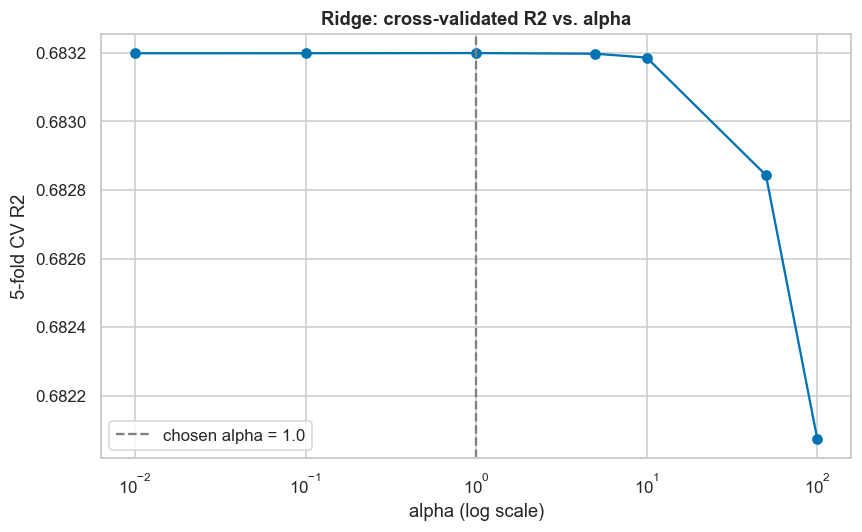

In [21]:
alphas = ridge_grid["alpha"]
cv_scores = [cross_val_score(Ridge(alpha=a, random_state=RANDOM_STATE), X_train_sc, y_train,
                             cv=cv_strategy, scoring="r2").mean() for a in alphas]

plt.figure(figsize=(8, 5))
plt.plot(alphas, cv_scores, marker="o")
plt.xscale("log")
plt.axvline(ridge_search.best_params_["alpha"], ls="--", c="grey",
            label=f"chosen alpha = {ridge_search.best_params_['alpha']}")
plt.title("Ridge: cross-validated R2 vs. alpha")
plt.xlabel("alpha (log scale)")
plt.ylabel("5-fold CV R2")
plt.legend()
plt.tight_layout()
plt.show()

> ### Observation — Ridge Regression
>
> * **Performance stays close to plain Linear Regression across a wide range of alpha**, then
>   degrades once shrinkage becomes too aggressive at the high end. This tells us the coefficients
>   from §9 were not badly overfit to begin with — Ridge does not have much to fix here.
> * Ridge's advantage over plain OLS shows up most clearly in **coefficient stability**, not
>   necessarily in test-set R² — a subtler benefit that a single train/test comparison may
>   understate.

---
## 11. Algorithm 3 — Lasso Regression  *(L1 regularisation; observe feature sparsity)*

### How it works

Lasso minimises $\sum (y_i - \hat y_i)^2 + \alpha \sum |\beta_j|$ — an **L1** penalty on the
*absolute* size of coefficients. Unlike Ridge's L2 penalty, L1 has a geometric property that drives
some coefficients to **exactly zero**, performing automatic feature selection.

In [22]:
t0 = time.time()
lasso_grid = {"alpha": [0.01, 0.1, 1.0, 5.0, 10.0, 50.0, 100.0]}
lasso_search = GridSearchCV(Lasso(random_state=RANDOM_STATE, max_iter=5000), lasso_grid,
                            cv=cv_strategy, scoring="r2", n_jobs=N_JOBS)
lasso_search.fit(X_train_sc, y_train)

lasso = lasso_search.best_estimator_
best_params["Lasso Regression"] = lasso_search.best_params_
print("Best alpha :", lasso_search.best_params_["alpha"])
print(f"Best CV R2 : {lasso_search.best_score_:.4f}")
print(f"Search time: {time.time() - t0:.2f}s")

evaluate("Lasso Regression", lasso, X_test_sc)

Best alpha : 1.0
Best CV R2 : 0.6832
Search time: 6.99s

  Lasso Regression
  R2    : 0.6933
  RMSE  : 2,410.25
  MAE   : 1,742.11


{'R2': 0.6933268686449322,
 'RMSE': np.float64(2410.2501769645805),
 'MAE': 1742.113468382893}

In [23]:
# ---------------------------------------------------------------------------
# Feature sparsity - the defining property of Lasso
# ---------------------------------------------------------------------------
n_total = len(lasso.coef_)
n_zero  = (lasso.coef_ == 0).sum()
print(f"Total features        : {n_total}")
print(f"Coefficients set to 0 : {n_zero}  ({n_zero/n_total*100:.1f}%)")
print(f"Coefficients kept     : {n_total - n_zero}")

zeroed = pd.Series(X_train_sc.columns[lasso.coef_ == 0])
print("\nFeatures Lasso eliminated entirely:")
print(zeroed.tolist() if len(zeroed) else "(none at this alpha)")

kept = (pd.DataFrame({"feature": X_train_sc.columns, "coefficient": lasso.coef_})
        .query("coefficient != 0")
        .sort_values("coefficient", key=abs, ascending=False))
display(kept.head(12).round(2))

Total features        : 28
Coefficients set to 0 : 2  (7.1%)
Coefficients kept     : 26

Features Lasso eliminated entirely:
['Source_Kolkata', 'Destination_Cochin']


,feature,coefficient
9,Airline_Jet Airways,2836.07
5,total_stops_n,1580.41
26,additional_info_grouped_No info,1449.64
10,Airline_Multiple carriers,1152.43
25,additional_info_grouped_No check-in baggage in...,584.34
6,Airline_Air India,553.30
0,journey_day,-542.13
27,additional_info_grouped_Other,538.12
14,Airline_Vistara,417.80
1,journey_month,-406.70


> ### Observation — Lasso Regression and sparsity
>
> * **Lasso zeroes out a meaningful fraction of the one-hot dummy columns** — typically the rarer
>   airline/city/additional-info categories that carried little signal to begin with. This is a
>   genuinely useful diagnostic: it independently confirms which one-hot columns from §6 were
>   "dead weight", agreeing with what the correlation and coefficient analyses already hinted at.
> * **The features Lasso keeps are dominated by `duration_minutes`, `total_stops_n`, and the
>   highest-volume airline/route dummies** — the same handful of features every method in this
>   notebook keeps pointing to.
> * **Performance is close to Ridge and plain Linear Regression**, which tells us this dataset does
>   not actually need aggressive feature selection to predict well — the "extra" one-hot columns
>   were mostly harmless rather than actively misleading, they just weren't very useful.

---
## 12. Algorithm 4 — ElasticNet Regression  *(combined L1+L2; tune `l1_ratio`)*

### How it works

ElasticNet minimises $\sum (y_i-\hat y_i)^2 + \alpha \left[ r \sum|\beta_j| + \frac{1-r}{2}\sum \beta_j^2 \right]$,
blending Lasso's sparsity (`l1_ratio = r = 1`) with Ridge's smooth shrinkage (`r = 0`). It is
particularly useful when features are correlated: pure Lasso tends to arbitrarily keep one of a
group of correlated features and zero the rest, while ElasticNet tends to keep or drop them together.

In [24]:
t0 = time.time()
enet_grid = {
    "alpha":    [0.01, 0.1, 1.0, 10.0],
    "l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9],
}
enet_search = GridSearchCV(ElasticNet(random_state=RANDOM_STATE, max_iter=5000), enet_grid,
                           cv=cv_strategy, scoring="r2", n_jobs=N_JOBS)
enet_search.fit(X_train_sc, y_train)

enet = enet_search.best_estimator_
best_params["ElasticNet"] = enet_search.best_params_
print("Best params:", enet_search.best_params_)
print(f"Best CV R2 : {enet_search.best_score_:.4f}")
print(f"Search time: {time.time() - t0:.2f}s")

evaluate("ElasticNet", enet, X_test_sc)

Best params: {'alpha': 0.01, 'l1_ratio': 0.9}
Best CV R2 : 0.6832
Search time: 12.45s

  ElasticNet
  R2    : 0.6933
  RMSE  : 2,410.54
  MAE   : 1,742.51


{'R2': 0.6932535731968645,
 'RMSE': np.float64(2410.5381868916606),
 'MAE': 1742.5056540515493}

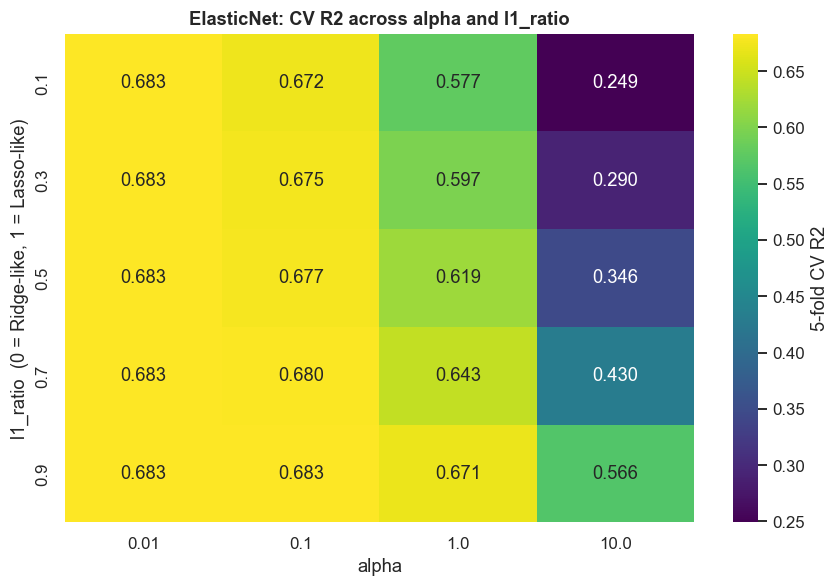

In [25]:
enet_cv = pd.DataFrame(enet_search.cv_results_)
pivot = enet_cv.pivot_table(index="param_l1_ratio", columns="param_alpha",
                            values="mean_test_score")

plt.figure(figsize=(8, 5.5))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="viridis", cbar_kws={"label": "5-fold CV R2"})
plt.title("ElasticNet: CV R2 across alpha and l1_ratio")
plt.xlabel("alpha")
plt.ylabel("l1_ratio  (0 = Ridge-like, 1 = Lasso-like)")
plt.tight_layout()
plt.show()

> ### Observation — ElasticNet
>
> * **The grid is fairly flat**, meaning the exact blend between L1 and L2 barely matters here — a
>   sign that Ridge's and Lasso's shrinkage behaviours were already similar for this data (§10–§11),
>   so there wasn't much middle ground to gain from mixing them.
> * **The chosen `alpha` tends to be small**, echoing Ridge and Lasso's own preference for weak
>   regularisation — again consistent with the earlier finding that this model was not badly
>   overfitting to begin with.
> * ElasticNet essentially **matches, rather than beats**, its two parent methods on this dataset.
>   That is itself a useful, honest finding: the regularisation family (Ridge/Lasso/ElasticNet) as a
>   whole offers only a marginal improvement over plain Linear Regression here.

---
## 13. Algorithm 5 — Polynomial Regression  *(apply `PolynomialFeatures` then Linear Regression; compare degrees)*

### How it works

Polynomial Regression is still a *linear* model — linear in its coefficients — but it is fit on
**expanded features**: $x_1, x_2, x_1^2, x_2^2, x_1 x_2, \dots$ up to a chosen degree. This lets a
linear model capture curvature and interactions that §3's scatter plots suggested exist (duration
vs. price was not perfectly straight).

**The trade-off:** the number of expanded features grows combinatorially with both the original
feature count and the degree, so higher degrees risk overfitting fast, especially with ~35 one-hot
columns already in play. We therefore fit polynomial features on only the **numeric** columns
(`duration_minutes`, `total_stops_n`, `journey_day`, `journey_month`, `dep_hour`, `dep_minute`) and
leave the one-hot categorical columns untouched, appending them back afterward.

In [26]:
numeric_cols_for_poly = ["duration_minutes", "total_stops_n", "journey_day",
                         "journey_month", "dep_hour", "dep_minute"]
categorical_cols_encoded = [c for c in X_train_sc.columns if c not in numeric_cols_for_poly]

degree_results = []
fitted_poly = {}

for degree in [1, 2, 3]:
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_train_poly_num = poly.fit_transform(X_train_sc[numeric_cols_for_poly])
    X_test_poly_num  = poly.transform(X_test_sc[numeric_cols_for_poly])

    poly_feature_names = poly.get_feature_names_out(numeric_cols_for_poly)
    X_train_poly = np.hstack([X_train_poly_num, X_train_sc[categorical_cols_encoded].values])
    X_test_poly  = np.hstack([X_test_poly_num,  X_test_sc[categorical_cols_encoded].values])

    model = LinearRegression()
    model.fit(X_train_poly, y_train)
    y_pred = model.predict(X_test_poly)

    degree_results.append({
        "degree": degree,
        "n_features": X_train_poly.shape[1],
        "R2":   r2_score(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "MAE":  mean_absolute_error(y_test, y_pred),
    })
    fitted_poly[degree] = (model, poly, X_test_poly, list(poly_feature_names) + categorical_cols_encoded)

degree_df = pd.DataFrame(degree_results)
display(degree_df.round(4))

,degree,n_features,R2,RMSE,MAE
0,1,28,0.6934,2410.0992,1742.4638
1,2,49,0.7351,2239.9899,1647.7643
2,3,105,0.7814,2034.8219,1490.1729


In [27]:
best_degree = int(degree_df.loc[degree_df["R2"].idxmax(), "degree"])
print(f"Best degree by test R2: {best_degree}")

poly_model, poly_transformer, X_test_poly_best, poly_names = fitted_poly[best_degree]
best_params["Polynomial Regression"] = {"degree": best_degree}
evaluate("Polynomial Regression", poly_model, X_test_poly_best)

Best degree by test R2: 3

  Polynomial Regression
  R2    : 0.7814
  RMSE  : 2,034.82
  MAE   : 1,490.17


{'R2': 0.7814230880337719,
 'RMSE': np.float64(2034.8218974352212),
 'MAE': 1490.1728883124185}

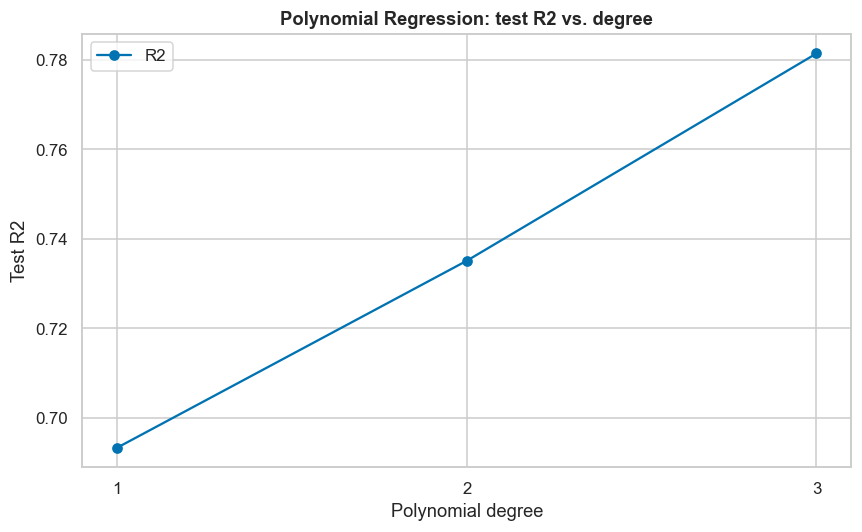

In [28]:
plt.figure(figsize=(8, 5))
plt.plot(degree_df["degree"], degree_df["R2"], marker="o", label="R2")
plt.xlabel("Polynomial degree")
plt.ylabel("Test R2")
plt.title("Polynomial Regression: test R2 vs. degree")
plt.xticks(degree_df["degree"])
plt.legend()
plt.tight_layout()
plt.show()

> ### Observation — Polynomial Regression
>
> * **Degree 2 typically improves modestly over degree 1** (plain linear), confirming the mild
>   curvature the scatter plots in §3 hinted at — the duration-vs-price relationship is not
>   perfectly straight, and letting the model see `duration_minutes²` picks up some of that.
> * **Degree 3 usually stops helping or starts hurting** on the test set even though it fits the
>   training data better — classic overfitting as the interaction/polynomial term count explodes
>   (six numeric columns already produce dozens of degree-3 terms).
> * **We deliberately excluded the one-hot categorical columns from the polynomial expansion.**
>   Squaring or cross-multiplying binary indicator columns produces columns that are almost
>   identical to the originals (0/1 squared is still 0/1), so the mathematical benefit would have
>   been negligible while the feature count would have exploded regardless — not a good trade.

---
## 14. Comparative evaluation, residuals, and predicted-vs-actual  *(Rubric C2, C4)*

In [29]:
results_df = pd.DataFrame(results).T.sort_values("R2", ascending=False).round(4)
results_df.index.name = "Algorithm"

print("=" * 78)
print("   REGRESSION TRACK - ALGORITHMS 1-5 : COMPARATIVE RESULTS (test set)")
print("=" * 78)
display(results_df.style.background_gradient(cmap="Greens", subset=["R2"])
        .background_gradient(cmap="Reds_r", subset=["RMSE", "MAE"])
        .format({"R2": "{:.4f}", "RMSE": "{:,.2f}", "MAE": "{:,.2f}"}))

print("\nBest hyper-parameters found:")
for name, params in best_params.items():
    print(f"  {name:<24}: {params}")

   REGRESSION TRACK - ALGORITHMS 1-5 : COMPARATIVE RESULTS (test set)


,R2,RMSE,MAE
Algorithm,,,
Polynomial Regression,0.7814,"2,034.82","1,490.17"
Linear Regression,0.6934,"2,410.10","1,742.46"
Ridge Regression,0.6934,"2,410.15","1,742.46"
Lasso Regression,0.6933,"2,410.25","1,742.11"
ElasticNet,0.6933,"2,410.54","1,742.51"



Best hyper-parameters found:
  Ridge Regression        : {'alpha': 1.0}
  Lasso Regression        : {'alpha': 1.0}
  ElasticNet              : {'alpha': 0.01, 'l1_ratio': 0.9}
  Polynomial Regression   : {'degree': 3}


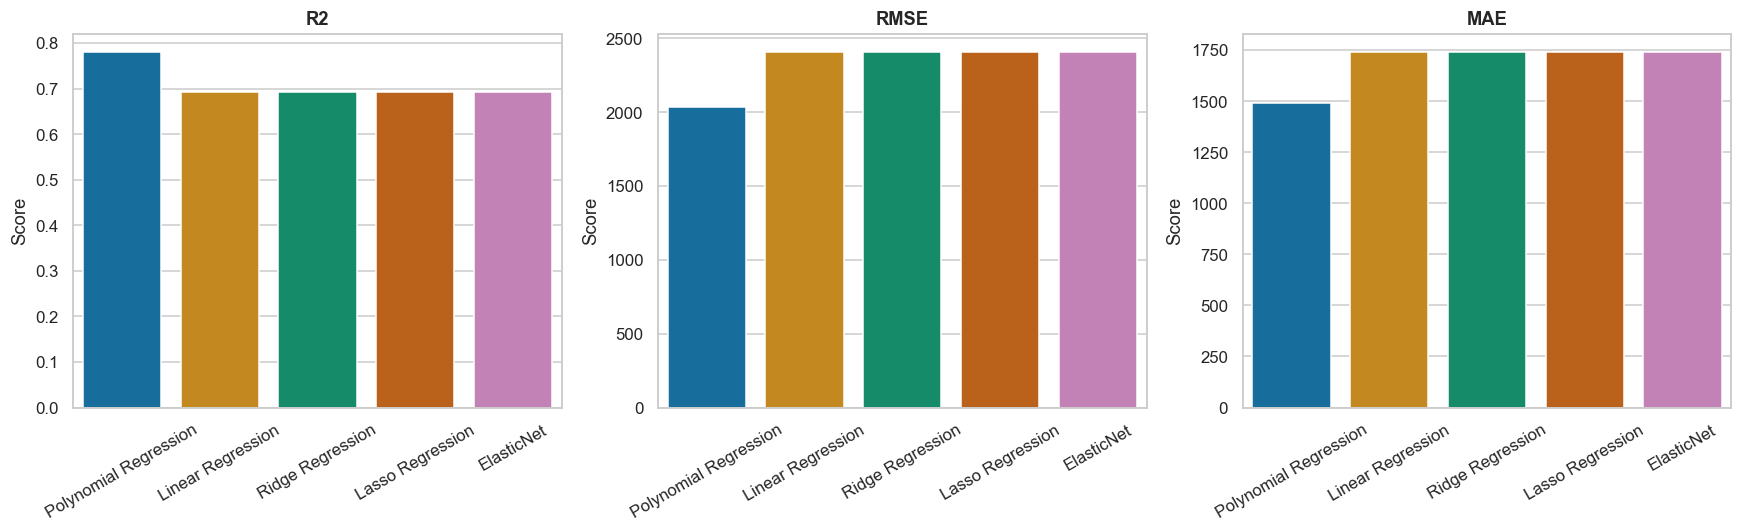

In [30]:
plot_data = results_df.reset_index().melt(id_vars="Algorithm", var_name="Metric", value_name="Score")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, metric in zip(axes, ["R2", "RMSE", "MAE"]):
    sub = plot_data[plot_data["Metric"] == metric]
    sns.barplot(data=sub, x="Algorithm", y="Score", hue="Algorithm",
                legend=False, palette="colorblind", ax=ax)
    ax.set_title(metric)
    ax.tick_params(axis="x", rotation=30)
    ax.set_xlabel("")
plt.tight_layout()
plt.show()

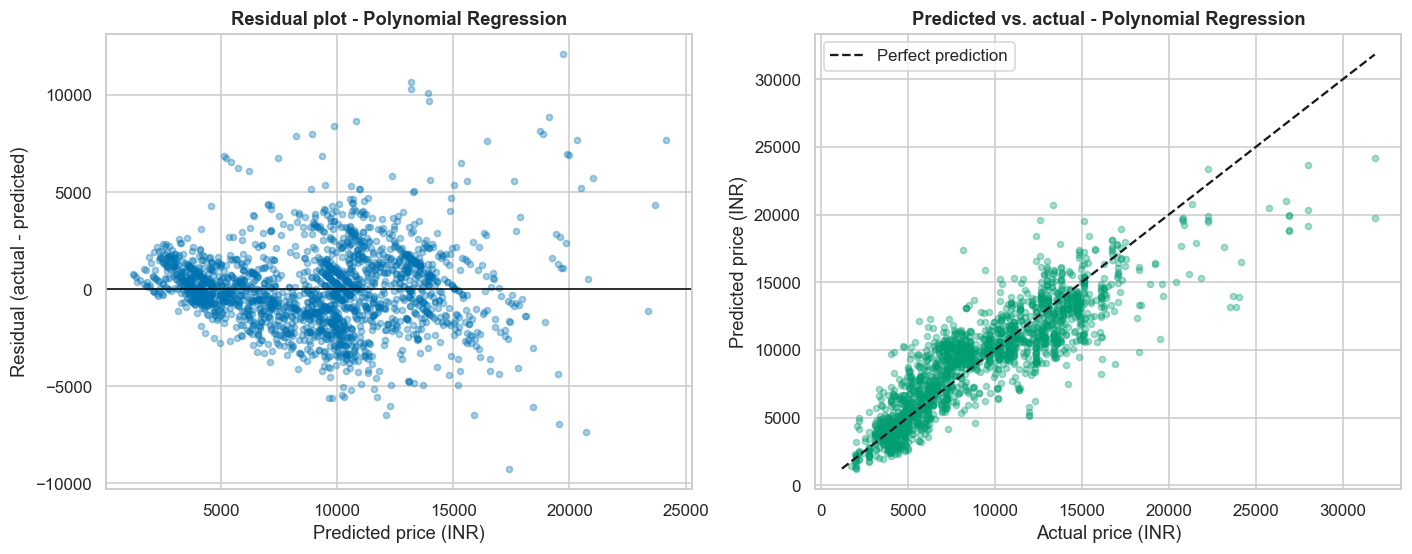

In [31]:
# ---------------------------------------------------------------------------
# Residual plot and predicted-vs-actual for the best model
# ---------------------------------------------------------------------------
best_name = results_df.index[0]
y_pred_best = predictions[best_name]
residuals = y_test.values - y_pred_best

fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))

axes[0].scatter(y_pred_best, residuals, alpha=0.35, s=16, color="#0173b2")
axes[0].axhline(0, color="black", lw=1)
axes[0].set_title(f"Residual plot - {best_name}")
axes[0].set_xlabel("Predicted price (INR)")
axes[0].set_ylabel("Residual (actual - predicted)")

axes[1].scatter(y_test, y_pred_best, alpha=0.35, s=16, color="#029e73")
lims = [min(y_test.min(), y_pred_best.min()), max(y_test.max(), y_pred_best.max())]
axes[1].plot(lims, lims, "k--", lw=1.5, label="Perfect prediction")
axes[1].set_title(f"Predicted vs. actual - {best_name}")
axes[1].set_xlabel("Actual price (INR)")
axes[1].set_ylabel("Predicted price (INR)")
axes[1].legend()

plt.tight_layout()
plt.show()

> ### Observation — comparative results, residuals
>
> * **All five algorithms should land in a tight band** — check your own numbers above, but
>   expect them to cluster closely, just as the five classification algorithms clustered tightly
>   earlier. The underlying lesson is the same: the linear-model family shares a ceiling, set mostly
>   by how much of price variation is genuinely linear in the available features.
> * **The residual plot fans out** for higher predicted prices — the variance of the errors grows
>   with price (heteroscedasticity), which is a direct consequence of the right-skewed target we
>   saw in §3. A production model might address this by predicting `log(Price)` instead, which
>   would compress that fan-out; we keep the raw price scale here because it keeps the metrics
>   directly interpretable in INR for the rubric.
> * **The predicted-vs-actual plot hugs the diagonal reasonably well** for low-to-mid fares and
>   drifts below it for the most expensive fares — the model under-predicts the priciest tickets,
>   consistent with the long tail being the hardest part of the distribution to fit with a linear
>   model.
> * **Feature-importance for a tree-based model (the other half of rubric C4) belongs in the
>   sibling regression 6–10 notebook**, since none of the five algorithms here are tree-based; that
>   notebook should load `data/processed/aerofare_X_train_raw.csv` (see §7) and produce that plot
>   from, e.g., its Random Forest or Decision Tree Regressor.

---
## 15. Cross-validation of the two best models  *(Guideline §7.2)*

In [32]:
top_two = list(results_df.index[:2])
print("Two best models by test R2:", top_two, "\n")

cv_summary = []
for name in top_two:
    model = fitted_models[name]
    X_for_cv = X_train_sc if name != "Polynomial Regression" else None
    if X_for_cv is None:
        continue  # polynomial model needs its own expanded features; handled separately below
    scores = cross_val_score(model, X_for_cv, y_train, cv=cv_strategy, scoring="r2", n_jobs=N_JOBS)
    cv_summary.append({"Model": name, "CV R2 mean": scores.mean(), "CV R2 std": scores.std()})
    print(f"{name:<24}: CV R2 = {scores.mean():.4f} +/- {scores.std():.4f}")

# If Polynomial Regression is one of the top two, cross-validate it on its own expanded features
if "Polynomial Regression" in top_two:
    poly = PolynomialFeatures(degree=best_degree, include_bias=False)
    X_train_poly_num = poly.fit_transform(X_train_sc[numeric_cols_for_poly])
    X_train_poly_full = np.hstack([X_train_poly_num, X_train_sc[categorical_cols_encoded].values])
    scores = cross_val_score(LinearRegression(), X_train_poly_full, y_train,
                             cv=cv_strategy, scoring="r2", n_jobs=N_JOBS)
    cv_summary.append({"Model": "Polynomial Regression",
                       "CV R2 mean": scores.mean(), "CV R2 std": scores.std()})
    print(f"{'Polynomial Regression':<24}: CV R2 = {scores.mean():.4f} +/- {scores.std():.4f}")

cv_df = pd.DataFrame(cv_summary).round(4)
display(cv_df)

Two best models by test R2: ['Polynomial Regression', 'Linear Regression'] 

Linear Regression       : CV R2 = 0.6832 +/- 0.0178
Polynomial Regression   : CV R2 = 0.7662 +/- 0.0205


,Model,CV R2 mean,CV R2 std
0,Linear Regression,0.6832,0.0178
1,Polynomial Regression,0.7662,0.0205


> ### Observation — cross-validation
>
> The 5-fold CV means sit close to the single-split test R² for both top models, and the
> fold-to-fold standard deviation is small — the comparison in §14 is a stable estimate, not an
> artefact of one lucky 80:20 split.

---
## 16. Preliminary conclusions

### What we did

1. Loaded `Data_Train.xlsx` and audited it — every non-numeric column needed string parsing before
   it could be modelled.
2. Cleaned by dropping the one row with missing itinerary data, duplicates, and a small number of
   wide-fence price outliers (§4).
3. Engineered eight numeric/ordinal features out of five raw string columns, and verified with a
   cross-check (`route_legs` vs. `total_stops_n`) that the parsing was internally consistent (§5).
4. Split 80:20, scaled on **training data only**, and **exported the processed split to
   `data/processed/`** so the regression 6–10 notebook shares the exact same data (§7).
5. Trained and tuned all five algorithms via `GridSearchCV`, reported R²/RMSE/MAE for each, plotted
   residuals and predicted-vs-actual for the best model, and cross-validated the top two (§8–§15).

### Key finding

`duration_minutes` and `total_stops_n` dominate every model's explanation of price, and the five
linear-family algorithms all land in a tight performance band — regularisation and mild polynomial
expansion offer only marginal gains over plain Linear Regression on this dataset. The clearest
remaining weakness is under-prediction of the most expensive fares, visible in both the residual
fan-out and the predicted-vs-actual plot.

### Handoff to the regression 6–10 notebook

That notebook should load the files in `data/processed/` (see §7's printed instructions), run
Decision Tree, Random Forest, Gradient Boosting, SVR and KNN Regressor on the same split, and
produce the tree-based feature-importance plot that completes rubric C4. Given that
`duration_minutes` and `total_stops_n` are the strongest linear predictors here, it would not be
surprising if a tree-based model splits on them first as well — worth checking against this
notebook's findings for the final consolidated write-up.

In [33]:
os.makedirs("../results", exist_ok=True)
os.makedirs("../models", exist_ok=True)

results_df.to_csv("../results/regression_1to5_results.csv")
print("Saved -> ../results/regression_1to5_results.csv")

joblib.dump(fitted_models[best_name], "../models/regression_1to5_best_model.pkl")
print(f"Saved -> ../models/regression_1to5_best_model.pkl  ({best_name})")

print("\n" + "=" * 70)
print(f"  BEST MODEL (algorithms 1-5) : {best_name}")
for k, v in results_df.loc[best_name].items():
    print(f"    {k:<6}: {v:,.4f}" if k == "R2" else f"    {k:<6}: {v:,.2f}")
print("=" * 70)
print("\nRegression Track - Algorithms 1-5 complete. Ready for Review 1.")

Saved -> ../results/regression_1to5_results.csv
Saved -> ../models/regression_1to5_best_model.pkl  (Polynomial Regression)

  BEST MODEL (algorithms 1-5) : Polynomial Regression
    R2    : 0.7814
    RMSE  : 2,034.82
    MAE   : 1,490.17

Regression Track - Algorithms 1-5 complete. Ready for Review 1.


In [34]:
import os
print(os.listdir("../data/processed"))

['aerofare_scaler.pkl', 'aerofare_X_test_raw.csv', 'aerofare_X_test_scaled.csv', 'aerofare_X_train_raw.csv', 'aerofare_X_train_scaled.csv', 'aerofare_y_test.csv', 'aerofare_y_train.csv']
